<a href="https://colab.research.google.com/github/Pranaam19/Experiments/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(df.head())

print("Shape:",df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
print(df.describe())

print("\nCateogircal Columns")
print(df.select_dtypes(include='object').columns.tolist())

print("\nNumerical  Columns")
print(df.select_dtypes(include=np.number).columns.tolist())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Sh

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
             Missing Values  Missing Values Percentage
PassengerId               0                   0.000000
Survived                  0                   0.000000
Pclass                    0                   0.000000
Name                      0                   0.000000
Sex                       0                   0.000000
Age                     177                  19.865320
SibSp                     0                   0.000000
Parch                     0                   0.000000
Ticket                    0                   0.000000
Fare                      0                   0.000000
Cabin                   687                  77.104377
Embarked                  2                   0.224467


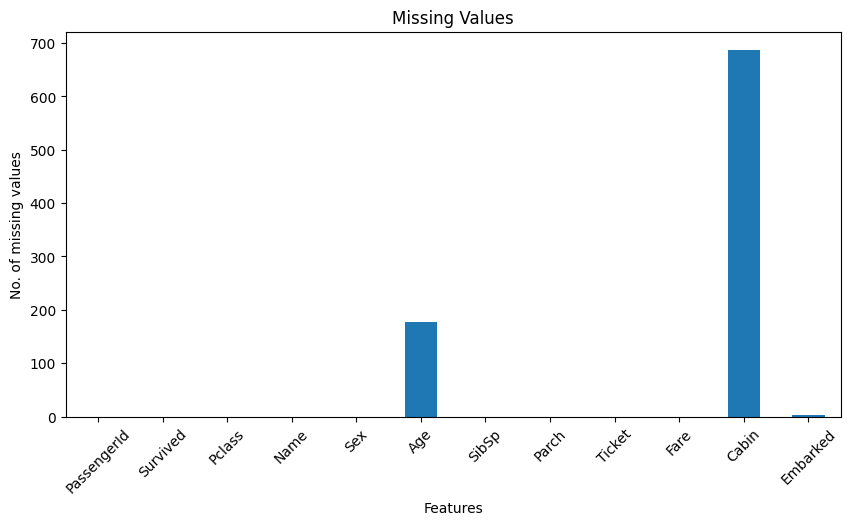

Duplicated 0


In [13]:
missing = df.isnull().sum()

print(missing)

missing_precent = (df.isnull().sum()/len(df))*100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Values Percentage": missing_precent
})


print(missing_table)


plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values")
plt.xlabel("Features")
plt.ylabel("No. of missing values")
plt.xticks(rotation=45)
plt.show()


print("Duplicated",df.duplicated().sum())

In [27]:
df_mean = df.copy()

mean_age = df_mean['Age'].mean()

df_mean['Age'] = df_mean['Age'].fillna(mean_age)

print("Remaining missing Age values: ",df_mean['Age'].isnull().sum())

df_median = df.copy()


median_age = df_median['Age'].median()

df_median['Age'] = df_median['Age'].fillna(median_age)

print("Remaining missing Age values: ",df_median['Age'].isnull().sum())

df_mode  = df.copy()

mode_embarked = df_mode['Embarked'].mode()[0]

print("Mean Age ",df['Age'].mean())
print("Median Age",df['Age'].median())

df_mode['Embarked'] = df_mode['Embarked'].fillna(mode_embarked)

print("Remaining missing Embarked values: ",df_mode['Embarked'].isnull().sum())

Remaining missing Age values:  0
Remaining missing Age values:  0
Mean Age  29.69911764705882
Median Age 28.0
Remaining missing Embarked values:  0


In [28]:
#Encoding

In [33]:
#Encoding - One-Hot

print(df[['Sex','Embarked']].head(10))

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = encoder.fit_transform(df[['Sex','Embarked']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Sex','Embarked'])
)

print(encoded_df.head())


#Encoding - Label
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Survived_encoded'] = le.fit_transform(df['Survived'])

print(df[['Survived','Survived_encoded']].head())

      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S
8  female        S
9  female        C
   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Embarked_nan
0         0.0       1.0         0.0         0.0         1.0           0.0
1         1.0       0.0         1.0         0.0         0.0           0.0
2         1.0       0.0         0.0         0.0         1.0           0.0
3         1.0       0.0         0.0         0.0         1.0           0.0
4         0.0       1.0         0.0         0.0         1.0           0.0
   Survived  Survived_encoded
0         0                 0
1         1                 1
2         1                 1
3         1                 1
4         0                 0


In [34]:
#Min-Max Scaling

features=df[['Age','Fare']].dropna()

print(features.describe())

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

scaled_minmax = minmax.fit_transform(features)

minmax_df = pd.DataFrame(
    scaled_minmax,
    columns=['Age','Fare']
)

print()

#Standardization

from sklearn.preprocessing import StandardScaler

std = StandardScaler()

scaled_standard = std.fit_transform(features)

standard_df  =pd.DataFrame(
    scaled_standard,
    columns=['Age','Fare']
)

print(standard_df.describe())

              Age        Fare
count  714.000000  714.000000
mean    29.699118   34.694514
std     14.526497   52.918930
min      0.420000    0.000000
25%     20.125000    8.050000
50%     28.000000   15.741700
75%     38.000000   33.375000
max     80.000000  512.329200

                Age          Fare
count  7.140000e+02  7.140000e+02
mean   2.338621e-16 -5.970947e-17
std    1.000701e+00  1.000701e+00
min   -2.016979e+00 -6.560759e-01
25%   -6.595416e-01 -5.038498e-01
50%   -1.170488e-01 -3.583992e-01
75%    5.718310e-01 -2.495211e-02
max    3.465126e+00  9.032109e+00
